# Maze Route Finding with BFS

## Load Lib


In [1]:
from __future__ import annotations

from collections import deque
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

/Users/miphu/Projects/DAT301m/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Data

In [2]:
#!/bin/bash
!kaggle datasets download mexwell/maze-dataset --unzip -p "./data/maze"

Dataset URL: https://www.kaggle.com/datasets/mexwell/maze-dataset
License(s): CC0-1.0
100%|██████████████████████████████████████| 15.6M/15.6M [00:05<00:00, 3.27MB/s]



## Configuration


In [3]:
DATA_DIR = Path('data/maze')
OUTPUT_DIR = Path('data/maze-results')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

WALL = 1
FREE = 0
DIRS = [(-1, 0), (0, 1), (1, 0), (0, -1)]  # N, E, S, W

## Preview Sample

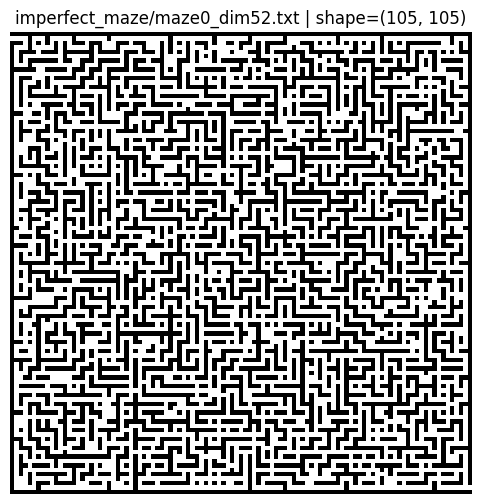

Found 3000 maze files


In [4]:
maze_paths = sorted(DATA_DIR.glob('*/*.txt'))
if not maze_paths:
    raise FileNotFoundError(f'No maze .txt files found under {DATA_DIR}')


def load_maze(path: Path) -> np.ndarray:
    return np.loadtxt(path, dtype=np.int64)


sample_path = maze_paths[0]
sample_maze = load_maze(sample_path)

plt.figure(figsize=(6, 6))
plt.imshow(sample_maze, cmap='gray_r', interpolation='nearest')
plt.title(f'{sample_path.parent.name}/{sample_path.name} | shape={sample_maze.shape}')
plt.axis('off')
plt.show()

print(f'Found {len(maze_paths)} maze files')


## BFS

In [5]:
def solve_maze_bfs(maze: np.ndarray) -> dict:
    Cell = tuple[int, int]
    start: Cell = (1, 0)
    goal: Cell = (maze.shape[0] - 2, maze.shape[1] - 1)
    queue = deque([start])
    parent: dict[Cell, Cell | None] = {start: None}

    while queue:
        row, col = queue.popleft()
        if (row, col) == goal:
            break

        for d_row, d_col in DIRS:
            next_row, next_col = row + d_row, col + d_col
            next_cell = (next_row, next_col)
            if not (0 <= next_row < maze.shape[0] and 0 <= next_col < maze.shape[1]):
                continue
            if maze[next_row, next_col] == WALL or next_cell in parent:
                continue
            parent[next_cell] = (row, col)
            queue.append(next_cell)
    else:
        raise ValueError('No route found')

    path: list[Cell] = []
    current = goal
    while current is not None:
        path.append(current)
        current = parent[current]
    path.reverse()

    return {
        'path': path,
        'operation_count': len(path) - 1,
    }


def solve_maze_bidirectional_bfs(maze: np.ndarray) -> dict:
    Cell = tuple[int, int]
    start: Cell = (1, 0)
    goal: Cell = (maze.shape[0] - 2, maze.shape[1] - 1)
    start_frontier = {start}
    goal_frontier = {goal}
    start_parent: dict[Cell, Cell | None] = {start: None}
    goal_parent: dict[Cell, Cell | None] = {goal: None}
    start_distance = {start: 0}
    goal_distance = {goal: 0}

    def expand_layer(
        frontier: set[Cell],
        own_parent: dict[Cell, Cell | None],
        own_distance: dict[Cell, int],
        other_distance: dict[Cell, int],
    ) -> tuple[set[Cell], Cell | None]:
        next_frontier: set[Cell] = set()
        meeting: Cell | None = None
        meeting_distance = float('inf')

        for row, col in frontier:
            for d_row, d_col in DIRS:
                next_row, next_col = row + d_row, col + d_col
                next_cell = (next_row, next_col)
                if not (0 <= next_row < maze.shape[0] and 0 <= next_col < maze.shape[1]):
                    continue
                if maze[next_row, next_col] == WALL or next_cell in own_parent:
                    continue

                own_parent[next_cell] = (row, col)
                own_distance[next_cell] = own_distance[(row, col)] + 1
                next_frontier.add(next_cell)
                if next_cell in other_distance:
                    distance = own_distance[next_cell] + other_distance[next_cell]
                    if distance < meeting_distance:
                        meeting = next_cell
                        meeting_distance = distance

        return next_frontier, meeting

    meeting = start if start == goal else None
    while meeting is None and start_frontier and goal_frontier:
        start_frontier, meeting = expand_layer(
            start_frontier, start_parent, start_distance, goal_distance
        )
        if meeting is not None:
            break
        goal_frontier, meeting = expand_layer(
            goal_frontier, goal_parent, goal_distance, start_distance
        )

    if meeting is None:
        raise ValueError('No route found')

    path = []
    current: Cell | None = meeting
    while current is not None:
        path.append(current)
        current = start_parent[current]
    path.reverse()

    current = goal_parent[meeting]
    while current is not None:
        path.append(current)
        current = goal_parent[current]

    return {
        'path': path,
        'operation_count': len(path) - 1,
    }


## Preview Solution


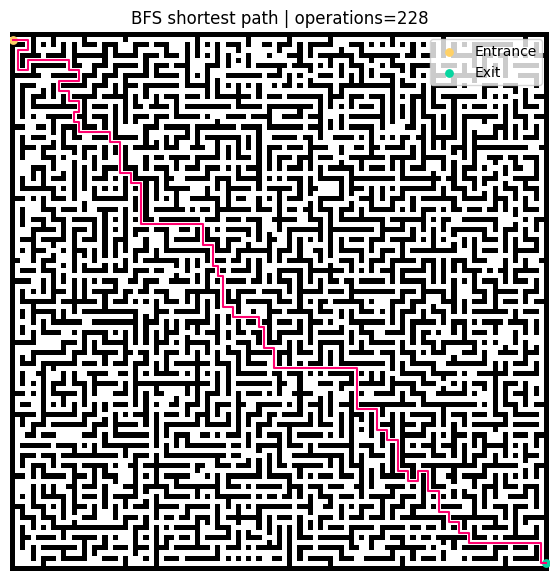

228

In [6]:
def plot_solution(maze: np.ndarray, solution: dict, title: str) -> None:
    plt.figure(figsize=(7, 7))
    plt.imshow(maze, cmap='gray_r', interpolation='nearest')
    rows = [row for row, _ in solution['path']]
    cols = [col for _, col in solution['path']]
    plt.plot(cols, rows, color='#ff006e', linewidth=1.5)
    plt.scatter([cols[0]], [rows[0]], color='#ffd166', s=28, label='Entrance')
    plt.scatter([cols[-1]], [rows[-1]], color='#06d6a0', s=28, label='Exit')
    plt.title(title)
    plt.axis('off')
    plt.legend()
    plt.show()


sample_solution = solve_maze_bfs(sample_maze)
sample_bidirectional_solution = solve_maze_bidirectional_bfs(sample_maze)
assert sample_bidirectional_solution['operation_count'] == sample_solution['operation_count']
plot_solution(sample_maze, sample_solution, f'BFS shortest path | operations={sample_solution["operation_count"]}')
sample_solution['operation_count']


## Solve Dataset

Run BFS on all perfect and imperfect mazes. This processes the complete dataset without a model-length limit.


In [7]:
records = []
for path in tqdm(maze_paths, desc='Solve mazes'):
    maze = load_maze(path)
    solution = solve_maze_bfs(maze)
    records.append({
        'maze_name': path.stem,
        'maze_kind': path.parent.name,
        'dim': (maze.shape[0] - 1) // 2,
        'rows': maze.shape[0],
        'cols': maze.shape[1],
        'operation_count': solution['operation_count'],
    })

results_df = pd.DataFrame(records)
results_df.head()


Solve mazes: 100%|██████████| 3000/3000 [00:31<00:00, 96.39it/s] 


,maze_name,maze_kind,dim,rows,cols,operation_count
0,maze0_dim52,imperfect_maze,52,105,105,228
1,maze1000_dim83,imperfect_maze,83,167,167,356
2,maze1001_dim28,imperfect_maze,28,57,57,170
3,maze1002_dim141,imperfect_maze,141,283,283,812
4,maze1003_dim57,imperfect_maze,57,115,115,320


## Export Results


In [8]:
average_operations = results_df['operation_count'].mean()
csv_path = OUTPUT_DIR / 'maze_operation_counts.csv'
excel_path = OUTPUT_DIR / 'maze_operation_counts.xlsx'
summary_path = OUTPUT_DIR / 'summary.csv'

results_df.to_csv(csv_path, index=False)
pd.DataFrame([{
    'total_mazes': len(results_df),
    'average_operations': average_operations,
    'minimum_operations': results_df['operation_count'].min(),
    'maximum_operations': results_df['operation_count'].max(),
}]).to_csv(summary_path, index=False)

try:
    results_df.to_excel(excel_path, index=False)
    print(f'Wrote {excel_path}')
except ImportError:
    print('openpyxl not installed; skipped .xlsx export and kept .csv output.')

print(f'Wrote {csv_path}')
print(f'Wrote {summary_path}')
print(f'Average operations: {average_operations:.4f}')


openpyxl not installed; skipped .xlsx export and kept .csv output.
Wrote data/maze-results/maze_operation_counts.csv
Wrote data/maze-results/summary.csv
Average operations: 2148.4313


## N-gram Model

Train an n-gram model from BFS solution paths to capture common movement patterns. 
The model learns P(next_move | previous_moves) from optimal paths.


In [9]:
from collections import defaultdict
import heapq

MOVE_MAP: dict[tuple[int, int], str] = {
    (-1, 0): 'U',
    (0, 1): 'R',
    (1, 0): 'D',
    (0, -1): 'L',
}

MOVE_VEC: dict[str, tuple[int, int]] = {
    'U': (-1, 0),
    'D': (1, 0),
    'L': (0, -1),
    'R': (0, 1),
}


def path_to_moves(path: list[tuple[int, int]]) -> list[str]:
    """Convert a grid path to a sequence of direction letters."""
    moves = []
    for i in range(1, len(path)):
        dr = path[i][0] - path[i - 1][0]
        dc = path[i][1] - path[i - 1][1]
        moves.append(MOVE_MAP[(dr, dc)])
    return moves


class NgramModel:
    """N-gram model with Laplace smoothing for move prediction."""

    def __init__(self, n: int = 3, alpha: float = 0.1) -> None:
        self.n = n
        self.alpha = alpha
        self.vocab_size = 4  # U, D, L, R
        self.context_counts: dict[tuple[str, ...], int] = defaultdict(int)
        self.transition_counts: dict[tuple[str, ...], dict[str, int]] = defaultdict(
            lambda: defaultdict(int)
        )

    def train(self, move_sequences: list[list[str]]) -> None:
        for moves in move_sequences:
            padded = ['START'] * (self.n - 1) + moves
            for i in range(len(padded) - self.n + 1):
                context = tuple(padded[i : i + self.n - 1])
                next_move = padded[i + self.n - 1]
                self.context_counts[context] += 1
                self.transition_counts[context][next_move] += 1

    def prob(self, context: tuple[str, ...], move: str) -> float:
        """P(move | context) with Laplace smoothing."""
        context = tuple(context)
        cnt_ctx = self.context_counts.get(context, 0)
        cnt_trans = self.transition_counts.get(context, {}).get(move, 0)
        return (cnt_trans + self.alpha) / (cnt_ctx + self.alpha * self.vocab_size)


# ── Collect BFS solution paths & train ──
print('Collecting BFS solution paths for n-gram training...')
all_moves: list[list[str]] = []
for p in tqdm(maze_paths, desc='Gather BFS paths'):
    maze = load_maze(p)
    solution = solve_maze_bfs(maze)
    moves = path_to_moves(solution['path'])
    all_moves.append(moves)

# Train trigram model
ngram = NgramModel(n=3, alpha=0.1)
ngram.train(all_moves)

total_contexts = len(ngram.context_counts)
total_transitions = sum(sum(d.values()) for d in ngram.transition_counts.values())
print(f'Trained trigram: {total_contexts} unique contexts, {total_transitions} transitions')

# Show sample probabilities
for ctx in [('R', 'R'), ('D', 'D'), ('R', 'D')]:
    print(f'\nP(move | {ctx}):')
    for move in ['U', 'D', 'L', 'R']:
        print(f'  {move}: {ngram.prob(ctx, move):.4f}')


Gather BFS paths: 100%|██████████| 3000/3000 [00:31<00:00, 94.04it/s] 


Trained trigram: 14 unique contexts, 6445294 transitions

P(move | ('R', 'R')):
  U: 0.1933
  D: 0.2554
  L: 0.0000
  R: 0.5513

P(move | ('D', 'D')):
  U: 0.0000
  D: 0.5490
  L: 0.1938
  R: 0.2571

P(move | ('R', 'D')):
  U: 0.0000
  D: 0.9830
  L: 0.0000
  R: 0.0170


## Cách A: N-gram Tie-break

N-gram chỉ dùng để phân giải khi nhiều node có cùng độ ưu tiên. 
BFS và A* vẫn giữ nguyên guarantee shortest path — n-gram chỉ ảnh hưởng thứ tự duyệt 
giữa các node cùng mức ưu tiên.


In [10]:
def solve_maze_bfs_ngram(maze: np.ndarray, ngram_model: NgramModel) -> dict:
    """BFS with n-gram tie-breaking: sort neighbours by n-gram probability."""
    Cell = tuple[int, int]
    start: Cell = (1, 0)
    goal: Cell = (maze.shape[0] - 2, maze.shape[1] - 1)
    queue = deque([(start, [], [])])  # (pos, path, move_history)
    visited = {start}
    expanded = 0

    while queue:
        pos, path, history = queue.popleft()
        expanded += 1
        if pos == goal:
            return {'path': path + [pos], 'operation_count': len(path), 'expanded_count': expanded}

        row, col = pos
        context = tuple(history[-(ngram_model.n - 1):])

        scored_moves = []
        for move_name, (d_row, d_col) in MOVE_VEC.items():
            nr, nc = row + d_row, col + d_col
            if not (0 <= nr < maze.shape[0] and 0 <= nc < maze.shape[1]):
                continue
            if maze[nr, nc] == WALL or (nr, nc) in visited:
                continue
            scored_moves.append((ngram_model.prob(context, move_name), move_name, (nr, nc)))

        scored_moves.sort(key=lambda x: x[0], reverse=True)

        for _score, move_name, next_cell in scored_moves:
            if next_cell not in visited:
                visited.add(next_cell)
                queue.append((next_cell, path + [pos], history + [move_name]))

    raise ValueError('No route found')


def solve_maze_astar_ngram_tiebreak(maze: np.ndarray, ngram_model: NgramModel) -> dict:
    """A* with n-gram tie-breaking: equal f-scores → prefer higher n-gram prob."""
    Cell = tuple[int, int]
    start: Cell = (1, 0)
    goal: Cell = (maze.shape[0] - 2, maze.shape[1] - 1)

    def h(cell: Cell) -> int:
        return abs(cell[0] - goal[0]) + abs(cell[1] - goal[1])

    counter = 0
    expanded = 0
    # Heap: (f_score, -ngram_score, tie_counter, g_score, pos, path, history)
    heap: list[tuple[int, float, int, int, Cell, list[Cell], list[str]]] = []
    heapq.heappush(heap, (h(start), 0.0, counter, 0, start, [], []))
    counter += 1
    best_g: dict[Cell, int] = {start: 0}

    while heap:
        f_score, neg_ngram, _counter, g_score, pos, path, history = heapq.heappop(heap)
        expanded += 1

        if pos == goal:
            return {'path': path + [pos], 'operation_count': len(path), 'expanded_count': expanded}

        if g_score > best_g.get(pos, float('inf')):
            continue

        row, col = pos
        context = tuple(history[-(ngram_model.n - 1):])

        for move_name, (d_row, d_col) in MOVE_VEC.items():
            nr, nc = row + d_row, col + d_col
            if not (0 <= nr < maze.shape[0] and 0 <= nc < maze.shape[1]):
                continue
            if maze[nr, nc] == WALL:
                continue

            new_g = g_score + 1
            if new_g >= best_g.get((nr, nc), float('inf')):
                continue

            best_g[(nr, nc)] = new_g
            ngram_score = ngram_model.prob(context, move_name)
            new_f = new_g + h((nr, nc))
            heapq.heappush(
                heap,
                (new_f, -ngram_score, counter, new_g, (nr, nc),
                 path + [pos], history + [move_name]),
            )
            counter += 1

    raise ValueError('No route found')


## Cách B: N-gram Weighted Heuristic

N-gram score được đưa trực tiếp vào f-score:  
**f(n) = g(n) + h(n) − λ × ngram_score(n)**

Node nào vừa gần goal vừa có hướng đi hợp pattern thì được ưu tiên hơn.  
Cách này mạnh hơn nhưng có thể làm mất guarantee shortest path nếu λ quá lớn.


In [11]:
def solve_maze_astar_ngram_weighted(
    maze: np.ndarray, ngram_model: NgramModel, lambda_ngram: float = 0.3
) -> dict:
    """A* with n-gram weighted into f-score: f(n) = g(n) + h(n) − λ × ngram_score."""
    Cell = tuple[int, int]
    start: Cell = (1, 0)
    goal: Cell = (maze.shape[0] - 2, maze.shape[1] - 1)

    def h(cell: Cell) -> int:
        return abs(cell[0] - goal[0]) + abs(cell[1] - goal[1])

    counter = 0
    expanded = 0
    heap: list[tuple[float, int, int, Cell, list[Cell], list[str]]] = []
    heapq.heappush(heap, (float(h(start)), counter, 0, start, [], []))
    counter += 1
    best_g: dict[Cell, int] = {start: 0}

    while heap:
        f_score, _counter, g_score, pos, path, history = heapq.heappop(heap)
        expanded += 1

        if pos == goal:
            return {'path': path + [pos], 'operation_count': len(path), 'expanded_count': expanded}

        if g_score > best_g.get(pos, float('inf')):
            continue

        row, col = pos
        context = tuple(history[-(ngram_model.n - 1):])

        for move_name, (d_row, d_col) in MOVE_VEC.items():
            nr, nc = row + d_row, col + d_col
            if not (0 <= nr < maze.shape[0] and 0 <= nc < maze.shape[1]):
                continue
            if maze[nr, nc] == WALL:
                continue

            new_g = g_score + 1
            if new_g >= best_g.get((nr, nc), float('inf')):
                continue

            best_g[(nr, nc)] = new_g
            ngram_score = ngram_model.prob(context, move_name)
            new_f = new_g + h((nr, nc)) - lambda_ngram * ngram_score
            heapq.heappush(
                heap,
                (new_f, counter, new_g, (nr, nc),
                 path + [pos], history + [move_name]),
            )
            counter += 1

    raise ValueError('No route found')


## Preview N-gram Solutions


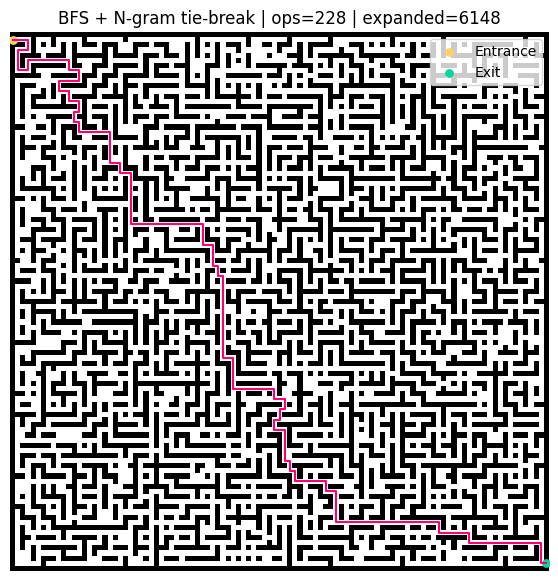

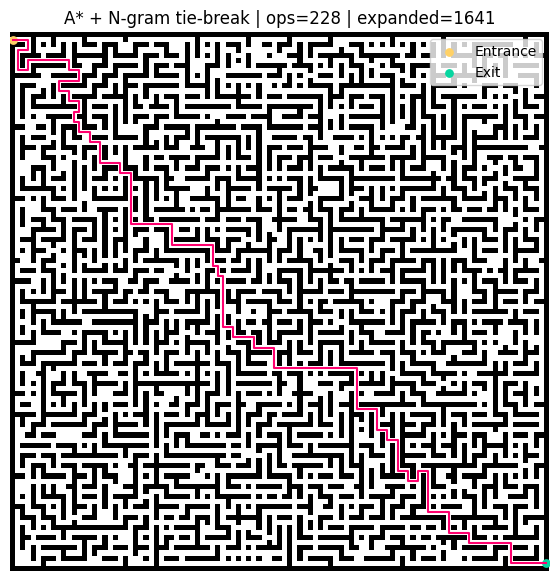

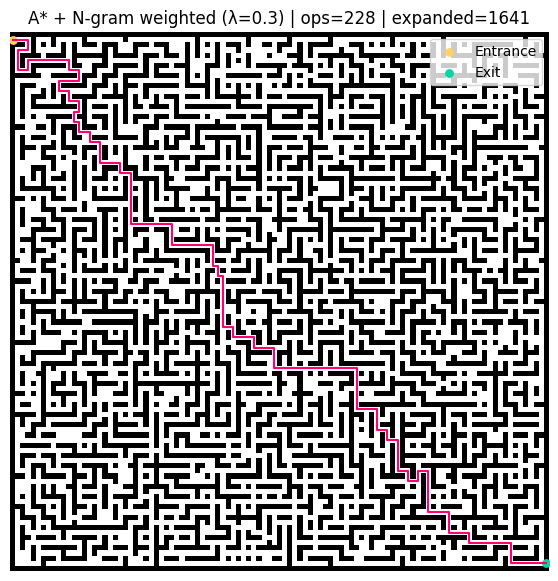

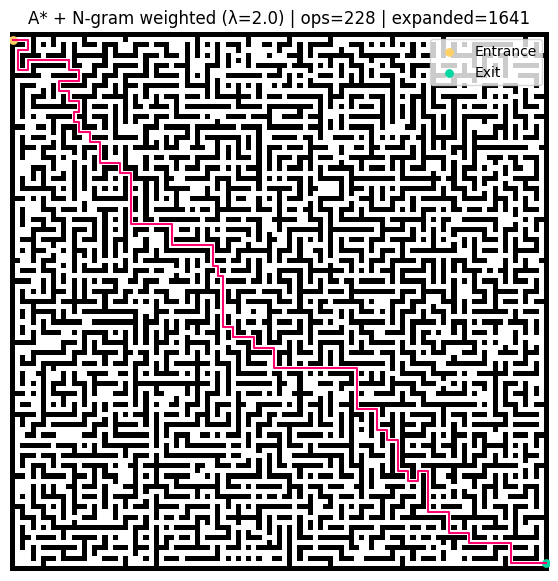

Method                             ops    expanded
--------------------------------------------------
Vanilla BFS                        228         N/A
BFS + N-gram tie                   228        6148
A* + N-gram tie                    228        1641
A* + N-gram w (λ=0.3)              228        1641
A* + N-gram w (λ=2.0)              228        1641


In [12]:
sample_bfs_ngram = solve_maze_bfs_ngram(sample_maze, ngram)
sample_astar_tie = solve_maze_astar_ngram_tiebreak(sample_maze, ngram)
sample_astar_w03 = solve_maze_astar_ngram_weighted(sample_maze, ngram, lambda_ngram=0.3)
sample_astar_w20 = solve_maze_astar_ngram_weighted(sample_maze, ngram, lambda_ngram=2.0)

plot_solution(sample_maze, sample_bfs_ngram,
              f'BFS + N-gram tie-break | ops={sample_bfs_ngram["operation_count"]} | expanded={sample_bfs_ngram["expanded_count"]}')
plot_solution(sample_maze, sample_astar_tie,
              f'A* + N-gram tie-break | ops={sample_astar_tie["operation_count"]} | expanded={sample_astar_tie["expanded_count"]}')
plot_solution(sample_maze, sample_astar_w03,
              f'A* + N-gram weighted (λ=0.3) | ops={sample_astar_w03["operation_count"]} | expanded={sample_astar_w03["expanded_count"]}')
plot_solution(sample_maze, sample_astar_w20,
              f'A* + N-gram weighted (λ=2.0) | ops={sample_astar_w20["operation_count"]} | expanded={sample_astar_w20["expanded_count"]}')

print(f'{"Method":30s}  {"ops":>6s}  {"expanded":>10s}')
print('-' * 50)
print(f'{"Vanilla BFS":30s}  {sample_solution["operation_count"]:>6d}  {"N/A":>10s}')
print(f'{"BFS + N-gram tie":30s}  {sample_bfs_ngram["operation_count"]:>6d}  {sample_bfs_ngram["expanded_count"]:>10d}')
print(f'{"A* + N-gram tie":30s}  {sample_astar_tie["operation_count"]:>6d}  {sample_astar_tie["expanded_count"]:>10d}')
print(f'{"A* + N-gram w (λ=0.3)":30s}  {sample_astar_w03["operation_count"]:>6d}  {sample_astar_w03["expanded_count"]:>10d}')
print(f'{"A* + N-gram w (λ=2.0)":30s}  {sample_astar_w20["operation_count"]:>6d}  {sample_astar_w20["expanded_count"]:>10d}')


## Solve Dataset — All Methods

Run all four solvers (vanilla BFS + 3 n-gram variants) on every maze and compare operation counts.


In [13]:
def solve_maze_bfs_expanded(maze: np.ndarray) -> dict:
    """Vanilla BFS with expanded node count for fair comparison."""
    Cell = tuple[int, int]
    start: Cell = (1, 0)
    goal: Cell = (maze.shape[0] - 2, maze.shape[1] - 1)
    queue = deque([start])
    parent: dict[Cell, Cell | None] = {start: None}
    expanded = 0

    while queue:
        row, col = queue.popleft()
        expanded += 1
        if (row, col) == goal:
            break

        for d_row, d_col in DIRS:
            next_row, next_col = row + d_row, col + d_col
            next_cell = (next_row, next_col)
            if not (0 <= next_row < maze.shape[0] and 0 <= next_col < maze.shape[1]):
                continue
            if maze[next_row, next_col] == WALL or next_cell in parent:
                continue
            parent[next_cell] = (row, col)
            queue.append(next_cell)
    else:
        raise ValueError('No route found')

    path: list[Cell] = []
    current = goal
    while current is not None:
        path.append(current)
        current = parent[current]
    path.reverse()

    return {
        'path': path,
        'operation_count': len(path) - 1,
        'expanded_count': expanded,
    }


METHODS: dict[str, object] = {
    'bfs_vanilla': solve_maze_bfs_expanded,
    'bfs_ngram': lambda m: solve_maze_bfs_ngram(m, ngram),
    'astar_tiebreak': lambda m: solve_maze_astar_ngram_tiebreak(m, ngram),
    'astar_weighted_03': lambda m: solve_maze_astar_ngram_weighted(m, ngram, lambda_ngram=0.3),
    'astar_weighted_20': lambda m: solve_maze_astar_ngram_weighted(m, ngram, lambda_ngram=2.0),
}

comparison_records: list[dict[str, object]] = []
for path in tqdm(maze_paths, desc='Solve with all methods'):
    maze = load_maze(path)
    record: dict[str, object] = {
        'maze_name': path.stem,
        'maze_kind': path.parent.name,
        'dim': (maze.shape[0] - 1) // 2,
        'rows': maze.shape[0],
        'cols': maze.shape[1],
    }
    for method_name, solver in METHODS.items():
        try:
            solution = solver(maze)
            record[method_name + '_ops'] = solution['operation_count']
            record[method_name + '_expanded'] = solution['expanded_count']
        except ValueError:
            record[method_name + '_ops'] = -1
            record[method_name + '_expanded'] = -1
    comparison_records.append(record)

comparison_df = pd.DataFrame(comparison_records)
comparison_df.head()


Solve with all methods: 100%|██████████| 3000/3000 [23:58<00:00,  2.09it/s]


,maze_name,maze_kind,dim,rows,cols,bfs_vanilla_ops,bfs_vanilla_expanded,bfs_ngram_ops,bfs_ngram_expanded,astar_tiebreak_ops,astar_tiebreak_expanded,astar_weighted_03_ops,astar_weighted_03_expanded,astar_weighted_20_ops,astar_weighted_20_expanded
0,maze0_dim52,imperfect_maze,52,105,105,228,6151,228,6148,228,1641,228,1641,228,1641
1,maze1000_dim83,imperfect_maze,83,167,167,356,15368,356,15364,356,5914,356,5914,356,5914
2,maze1001_dim28,imperfect_maze,28,57,57,170,1686,170,1685,170,1691,170,1691,170,1691
3,maze1002_dim141,imperfect_maze,141,283,283,812,41634,812,41635,812,35472,812,35472,812,35472
4,maze1003_dim57,imperfect_maze,57,115,115,320,6780,320,6779,320,4861,320,4861,320,4861


## Export N-gram Comparison


In [14]:
COMPARISON_DIR = Path('data/maze-results')
COMPARISON_DIR.mkdir(parents=True, exist_ok=True)

csv_path = COMPARISON_DIR / 'maze_ngram_comparison.csv'
comparison_df.to_csv(csv_path, index=False)

# ── Per-method summary ──
summary_rows = []
for method_name in METHODS:
    ops_col = method_name + '_ops'
    exp_col = method_name + '_expanded'
    valid_ops = comparison_df[comparison_df[ops_col] >= 0][ops_col]
    valid_exp = comparison_df[comparison_df[exp_col] >= 0][exp_col]
    summary_rows.append({
        'method': method_name,
        'solved': len(valid_ops),
        'avg_ops': round(valid_ops.mean(), 2),
        'total_ops': int(valid_ops.sum()),
        'avg_expanded': round(valid_exp.mean(), 1),
        'total_expanded': int(valid_exp.sum()),
    })

summary_df = pd.DataFrame(summary_rows)
summary_path = COMPARISON_DIR / 'maze_ngram_summary.csv'
summary_df.to_csv(summary_path, index=False)

print('=== Per-method Summary ===')
print(summary_df.to_string(index=False))
print(f'\nWrote {csv_path}')
print(f'Wrote {summary_path}')

# ── Delta vs vanilla BFS ──
vanilla_ops = int(comparison_df['bfs_vanilla_ops'].sum())
vanilla_exp = int(comparison_df['bfs_vanilla_expanded'].sum())
print(f'\n=== Operations (path length) ===')
for method_name in METHODS:
    col = method_name + '_ops'
    valid = comparison_df[comparison_df[col] >= 0][col]
    delta = int(valid.sum()) - vanilla_ops
    pct = (delta / vanilla_ops) * 100
    print(f'  {method_name:25s}: {int(valid.sum()):>10d}  (Δ={delta:>+8d}, {pct:>+.2f}%)')

print(f'\n=== Expanded nodes (search efficiency) ===')
for method_name in METHODS:
    col = method_name + '_expanded'
    valid = comparison_df[comparison_df[col] >= 0][col]
    delta = int(valid.sum()) - vanilla_exp
    pct = (delta / vanilla_exp) * 100
    print(f'  {method_name:25s}: {int(valid.sum()):>10d}  (Δ={delta:>+8d}, {pct:>+.2f}%)')


=== Per-method Summary ===
           method  solved  avg_ops  total_ops  avg_expanded  total_expanded
      bfs_vanilla    3000  2148.43    6445294       13338.8        40016502
        bfs_ngram    3000  2148.43    6445294       13337.5        40012498
   astar_tiebreak    3000  2148.43    6445294        9558.4        28675305
astar_weighted_03    3000  2148.43    6445294        9558.4        28675305
astar_weighted_20    3000  2148.43    6445294        9558.4        28675305

Wrote data/maze-results/maze_ngram_comparison.csv
Wrote data/maze-results/maze_ngram_summary.csv

=== Operations (path length) ===
  bfs_vanilla              :    6445294  (Δ=      +0, +0.00%)
  bfs_ngram                :    6445294  (Δ=      +0, +0.00%)
  astar_tiebreak           :    6445294  (Δ=      +0, +0.00%)
  astar_weighted_03        :    6445294  (Δ=      +0, +0.00%)
  astar_weighted_20        :    6445294  (Δ=      +0, +0.00%)

=== Expanded nodes (search efficiency) ===
  bfs_vanilla              :   

## Density-Driven Swarm (Bonus)

Based on Zamora Sánchez et al. (2025) — *"Maze-solving with density-driven swarms"*.

Memory-less agents interact only via **local density**: each agent decides to move with
probability `p = d / (d + η)` and follows the direction with the highest incoming agent
flow. A single kinetic parameter **η** controls the exploration–exploitation balance.

- **η → 0**: agents always move, follow the crowd → persistent tails
- **η large**: agents stall often → diffusive, random exploration
- **Optimal η**: balances persistence with exploration → swarm self-organizes to solve the maze

No visited set, no heap, no path memory. The path is extracted post-hoc from the density field.


In [15]:
def solve_maze_swarm(
    maze: np.ndarray,
    n_agents: int = 500,
    eta: float = 0.5,
    max_steps: int = 50000,
    seed: int | None = None,
) -> dict:
    """Density-driven swarm maze solver (CPU implementation).

    Ref: Zamora Sánchez et al., "Maze-solving with density-driven swarms" (2025)
    """
    rng = np.random.default_rng(seed)
    rows, cols = maze.shape

    # ── Build graph: free cells → node indices ──
    node_of: dict[tuple[int, int], int] = {}
    cell_of: dict[int, tuple[int, int]] = {}
    node_count = 0
    for r in range(rows):
        for c in range(cols):
            if maze[r, c] == FREE:
                node_of[(r, c)] = node_count
                cell_of[node_count] = (r, c)
                node_count += 1

    # Adjacency list
    adj: list[list[int]] = [[] for _ in range(node_count)]
    for r in range(rows):
        for c in range(cols):
            if maze[r, c] == WALL:
                continue
            u = node_of[(r, c)]
            for dr, dc in DIRS:
                nr, nc = r + dr, c + dc
                if 0 <= nr < rows and 0 <= nc < cols and maze[nr, nc] == FREE:
                    adj[u].append(node_of[(nr, nc)])

    dmax = max((len(a) for a in adj), default=0)
    if dmax == 0:
        raise ValueError('Maze has no free cells')

    # Neighbour → slot index mapping
    nbr_slot: list[dict[int, int]] = []
    for u in range(node_count):
        nbr_slot.append({v: j for j, v in enumerate(adj[u])})

    start_node = node_of[(1, 0)]
    goal_node = node_of[(rows - 2, cols - 1)]

    # ── Initialise agents at the entry ──
    positions = np.full(n_agents, start_node, dtype=np.int32)
    origins = positions.copy()

    # n_ij[i, j] = how many agents at node i came from neighbour slot j
    n_ij = np.zeros((node_count, dmax), dtype=np.int32)

    goal_reached_step = None
    total_moves = 0

    for step in range(max_steps):
        # ── Step 1: Sub-densities ──
        n_ij.fill(0)
        for a in range(n_agents):
            i = positions[a]
            o = origins[a]
            slot = nbr_slot[i].get(o)
            if slot is not None:
                n_ij[i, slot] += 1

        # ── Step 2: Densities & flows ──
        dns = n_ij.sum(axis=1)  # total agents per node
        flw = n_ij               # flow = sub-density

        # ── Step 3: Agent motion ──
        for a in range(n_agents):
            i = positions[a]
            deg = len(adj[i])
            if deg == 0:
                continue

            # Stall probability: p_move = density / (density + eta)
            d_i = dns[i]
            p_move = d_i / (d_i + eta) if d_i > 0 else 0.0

            if rng.random() >= p_move:
                continue  # Agent stalls

            total_moves += 1

            # Choose neighbour with max flow (random tie-break)
            row_flow = flw[i, :deg]
            if row_flow.sum() == 0:
                # No flow yet → random walk
                next_node = adj[i][rng.integers(0, deg)]
            else:
                max_f = row_flow.max()
                candidates = [adj[i][j] for j in range(deg) if row_flow[j] == max_f]
                next_node = candidates[rng.integers(0, len(candidates))]

            origins[a] = i
            positions[a] = next_node

        # ── Check goal ──
        if goal_node in positions:
            goal_reached_step = step + 1
            break

    if goal_reached_step is None:
        raise ValueError(f'Swarm did not reach goal within {max_steps} steps')

    # ── Extract path from density field (trace max incoming flow goal→start) ──
    path_nodes = [goal_node]
    current = goal_node
    seen = {goal_node}
    while current != start_node:
        flows_in = n_ij[current]
        if flows_in.sum() == 0:
            break
        best_j = int(np.argmax(flows_in))
        prev_node = adj[current][best_j]
        if prev_node in seen:
            break
        seen.add(prev_node)
        path_nodes.append(prev_node)
        current = prev_node

    path_nodes.reverse()
    if path_nodes[0] != start_node:
        path_nodes.insert(0, start_node)
    if path_nodes[-1] != goal_node:
        path_nodes.append(goal_node)

    path_cells = [cell_of[n] for n in path_nodes]

    return {
        'path': path_cells,
        'operation_count': len(path_cells) - 1,
        'expanded_count': total_moves,
        'steps': goal_reached_step,
    }


# ── Preview on sample maze ──
print('Running swarm on sample maze (eta=0.5, 500 agents)...')
sample_swarm = solve_maze_swarm(sample_maze, n_agents=500, eta=0.5, seed=42)

plot_solution(sample_maze, sample_swarm,
              f'Swarm (η=0.5) | ops={sample_swarm["operation_count"]} | moves={sample_swarm["expanded_count"]} | steps={sample_swarm["steps"]}')

print(f'Vanilla BFS:    {sample_solution["operation_count"]:>6d} ops (optimal)')
print(f'Swarm (η=0.5):  {sample_swarm["operation_count"]:>6d} ops')
print(f'  Steps to goal: {sample_swarm["steps"]}')
print(f'  Total moves:   {sample_swarm["expanded_count"]}')


Running swarm on sample maze (eta=0.5, 500 agents)...


ValueError: Swarm did not reach goal within 50000 steps

In [ ]:
# Try different η values on the sample maze
eta_values = [0.1, 0.3, 0.5, 1.0, 2.0]
results = []
for eta_val in eta_values:
    try:
        sol = solve_maze_swarm(sample_maze, n_agents=500, eta=eta_val, seed=42, max_steps=30000)
        results.append({
            'eta': eta_val,
            'ops': sol['operation_count'],
            'steps': sol['steps'],
            'moves': sol['expanded_count'],
            'status': 'OK',
        })
        print(f'η={eta_val:<4.1f}  ops={sol["operation_count"]:>6d}  steps={sol["steps"]:>8d}  moves={sol["expanded_count"]:>10d}')
    except ValueError as e:
        results.append({'eta': eta_val, 'ops': -1, 'steps': -1, 'moves': -1, 'status': 'FAIL'})
        print(f'η={eta_val:<4.1f}  FAILED: {e}')

eta_df = pd.DataFrame(results)
print(f'\nVanilla BFS optimal: {sample_solution["operation_count"]} ops')


In [ ]:
# Quick benchmark on first 30 mazes (swarm is CPU-bound, so keep subset small)
SWARM_ETA = 0.5
swarm_records = []
for path in tqdm(maze_paths[:30], desc='Swarm on 30 mazes'):
    maze = load_maze(path)
    bfs_sol = solve_maze_bfs(maze)
    try:
        sw_sol = solve_maze_swarm(maze, n_agents=500, eta=SWARM_ETA, max_steps=30000, seed=42)
        swarm_records.append({
            'maze_name': path.stem,
            'maze_kind': path.parent.name,
            'dim': (maze.shape[0] - 1) // 2,
            'bfs_ops': bfs_sol['operation_count'],
            'swarm_ops': sw_sol['operation_count'],
            'swarm_steps': sw_sol['steps'],
            'swarm_moves': sw_sol['expanded_count'],
        })
    except ValueError:
        swarm_records.append({
            'maze_name': path.stem,
            'maze_kind': path.parent.name,
            'dim': (maze.shape[0] - 1) // 2,
            'bfs_ops': bfs_sol['operation_count'],
            'swarm_ops': -1,
            'swarm_steps': -1,
            'swarm_moves': -1,
        })

swarm_df = pd.DataFrame(swarm_records)
solved = swarm_df[swarm_df['swarm_ops'] >= 0]
print(f'Solved: {len(solved)}/{len(swarm_df)} mazes')
if len(solved) > 0:
    print(f'Avg BFS ops:    {solved["bfs_ops"].mean():.1f}')
    print(f'Avg swarm ops:  {solved["swarm_ops"].mean():.1f}')
    print(f'Avg swarm steps:{solved["swarm_steps"].mean():.1f}')
    print(f'Overhead vs BFS: {((solved["swarm_ops"] - solved["bfs_ops"]).mean()):.1f} extra ops on average')
swarm_df.head(10)
